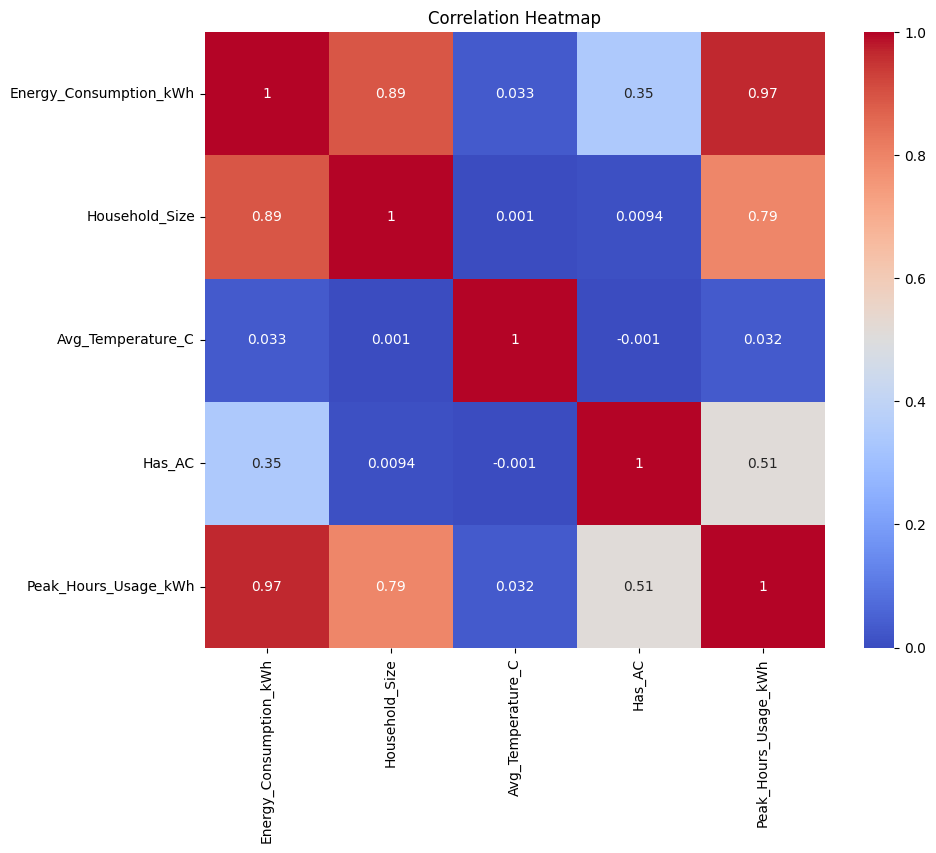

Energy_Consumption_kWh    1.000000
Peak_Hours_Usage_kWh      0.967641
Household_Size            0.893959
Has_AC                    0.346921
Avg_Temperature_C         0.033315
Name: Energy_Consumption_kWh, dtype: float64
Model coefficients: [ 0.94818442  0.02032814 -0.47554387  1.64864132]
Intercept: 0.019735269876708372
MAE: 0.625, RMSE: 0.787
R²: 0.980, Adjusted R²: 0.980
F-test statistic: 322663.144


In [42]:
# Import necessary libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from sklearn.metrics import mean_absolute_error,mean_squared_error


# Load dataset and remove unneeded columns
dataset=pd.read_csv("household_energy_consumption.csv")
dataset=dataset.drop(['Household_ID','Date'],axis=1)

# Encode categorical variables
label_encoder=LabelEncoder()
dataset['Has_AC']=label_encoder.fit_transform(dataset['Has_AC'])

# Split features (X) and target (y)
x=dataset.iloc[:,1:]
y=dataset['Energy_Consumption_kWh']

# Split training and testing data
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)

#Build and fit Linear Regression model
model=LinearRegression()
model.fit(x_train,y_train)

#Predict values for test set
y_pre=model.predict(x_test)

#Calculate error metrics: MAE, MSE, RMSE
MAE = mean_absolute_error(y_test,y_pre)
MSE = mean_squared_error(y_test,y_pre)
RMSE = np.sqrt(MSE)

# Calculate R² and Adjusted R²
R2 = model.score(x_test, y_test)
n = x_test.shape[0]  # Number of samples
p = x_test.shape[1]  # Number of features
Adj_R2 = 1 - (1-R2)*(n-1)/(n-p-1)

# Perform F-test for overall model significance
RSS = np.sum((y_test - y_pre)**2)
TSS = np.sum((y_test - np.mean(y_test))**2)
F = ((TSS - RSS)/p) / (RSS/(n-p-1))

#Visualize correlation heatmap
correlation_matrix=dataset.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Feature Correlation with Energy Consumption")
plt.show()
energy_corr = correlation_matrix["Energy_Consumption_kWh"].sort_values(ascending=False)
# Display model coefficients and evaluation metrics
print(energy_corr)

# Print correlation of features with target
print("Model coefficients:", model.coef_)
print("Intercept:", model.intercept_)
print(f"MAE: {MAE:.3f}, RMSE: {RMSE:.3f}")
print(f"R²: {R2:.3f}, Adjusted R²: {Adj_R2:.3f}")
print(f"F-test statistic: {F:.3f}")
